In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

from scipy.optimize import minimize_scalar

from Abelian_Potential import Abelian_Model


## Define the Model

In [3]:
# Parameters: strong FOPT regime (large g/sqrt(lam) ratio)
lam, mu, g = 0.05, 50.0, 1.0

model = Abelian_Model(lam, mu, g)

# Analytic expectations
v_tree  = mu / np.sqrt(lam)
mh_tree = np.sqrt(2.0) * mu
mA_tree = g * v_tree
print(f"Tree-level vev :  v  = {v_tree:.3f} GeV")
print(f"Tree-level Higgs: mh = {mh_tree:.3f} GeV")
print(f"Tree-level gauge: mA = {mA_tree:.3f} GeV")

# Numerical vev from Vtot(T=0)
T_eps = 1e-6  # numerically zero, avoids division by T=0

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), T_eps).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"\nNumerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - v_tree)/v_tree * 100:.3f}%")

Tree-level vev :  v  = 223.607 GeV
Tree-level Higgs: mh = 70.711 GeV
Tree-level gauge: mA = 223.607 GeV

Numerical vev (Vtot, T=0): 243.117 GeV
CW shift: 8.725%


## Coleman Weinberg ($T=0$)

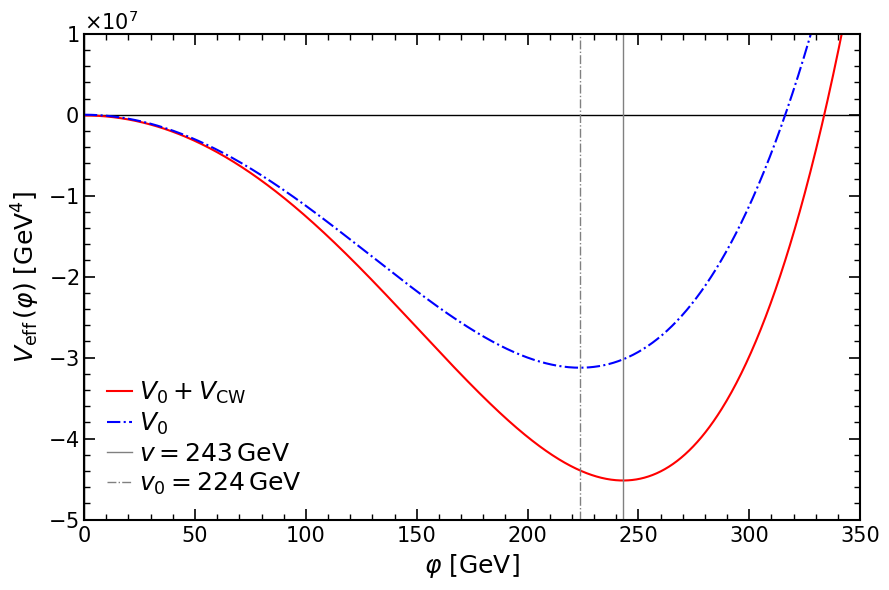

In [124]:
phi_vals = np.linspace(-50, 500, 1500)
X        = phi_vals[:, np.newaxis] 

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, V_tot_0, label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(phi_vals, V_tree, label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v_tree, label=rf'$v_0={v_tree:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-.', alpha=1)

ax.set_xlim(0, 350)
ax.set_ylim(-5e7,1e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False,
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig("figures\Abelian_CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Thermal Evolution

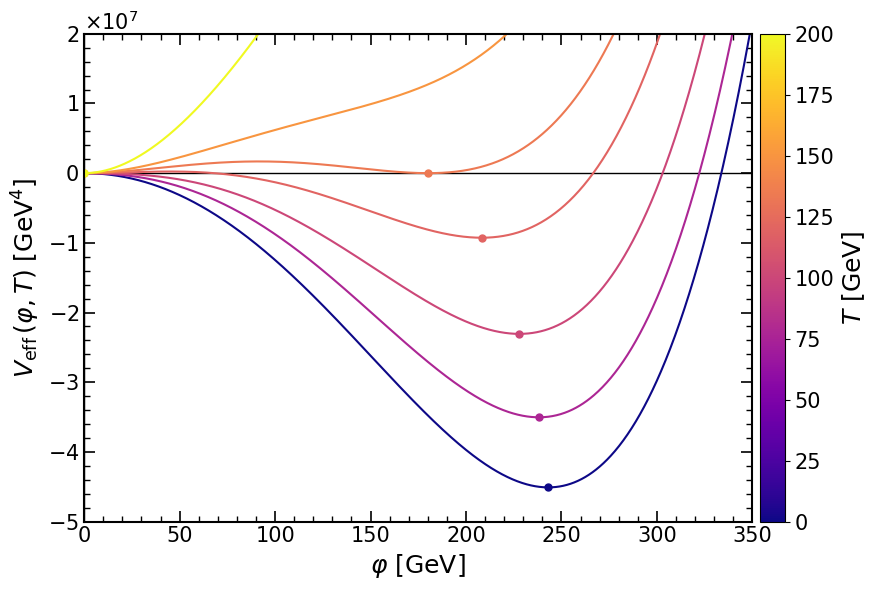

In [31]:
T_vals   = np.array([1e-6, 77, 100, 120, 132.85, 150, 200])
phi_vals = np.linspace(-10,400,1500)
X        = phi_vals[:, np.newaxis]

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
    V = model.Vtot(X, T)
    V_norm = V - model.Vtot(np.array([[0.0]]), T)
    color = cmap(norm(T))
    label = r'$T = 0$' if T < 1 else rf'$T = {T:.0f}$ GeV'
    ax.plot(phi_vals, V_norm, color=color, lw=1.5, label=label)

    # Mark the minimum of the broken phase
    mask = phi_vals > 0          # Impose Positive vev
    idx  = np.argmin(V[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = V[mask][idx]
    ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=5)

ax.set_xlim(0, 350)
ax.set_ylim(-5e7,2e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi, T)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Configure ticks
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.savefig("figures\Abelian_Thermal.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Phase Transition

In [ ]:
# Critical Temperature $T_c

In [15]:
# Find T_c & Transition strength
model.findAllTransitions()

for i, trans in enumerate(model.TnTrans):
    Tc   = trans["crit_trans"]['Tcrit']
    high = trans["crit_trans"]['high_vev']
    low  = trans["crit_trans"]['low_vev']
    xi_c = abs(low[0] - high[0]) / Tc
    print("=======================================================")
    print(f"Transition {i}:  Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.4f}")
    print("=======================================================")

Tunneling from phase 1 to phase 0 at T=105.6344
high_vev = [0.00208791]
low_vev = [223.77473624]
Path deformation converged. 1 steps. fRatio = 5.17554e-14
Tunneling from phase 1 to phase 0 at T=105.6349
high_vev = [0.00080552]
low_vev = [223.77433214]
Path deformation converged. 1 steps. fRatio = 7.74562e-14
Tunneling from phase 1 to phase 0 at T=121.8111
high_vev = [4.11996826e-18]
low_vev = [205.42744227]
Path deformation converged. 1 steps. fRatio = 6.13289e-14
Tunneling from phase 1 to phase 0 at T=129.8992
high_vev = [-2.60208521e-17]
low_vev = [189.0823387]
Path deformation converged. 1 steps. fRatio = 5.63793e-14
Tunneling from phase 1 to phase 0 at T=123.4162
high_vev = [4.29177653e-06]
low_vev = [202.77751171]
Path deformation converged. 1 steps. fRatio = 9.71165e-14
Tunneling from phase 1 to phase 0 at T=126.6577
high_vev = [1.28470262e-07]
low_vev = [196.64921586]
Path deformation converged. 1 steps. fRatio = 7.38035e-14
Tunneling from phase 1 to phase 0 at T=126.497
high_ve